## SVM model using TF-IDF Vectors with Unigram+Bigram

In [2]:
import json
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
filepath = 'yelp_academic_dataset_review.json'
reviews = []
with open(filepath, 'r', encoding='utf-8') as f:  
    for i, line in enumerate(f):
        if i >= 26000: 
            break
        review = json.loads(line)
        reviews.append({
            'review_id': review['review_id'],
            'user_id': review['user_id'],
            'business_id': review['business_id'],
            'stars': review['stars'],
            'date': review['date'],
            'text': review['text'],
            'useful': review['useful'],
            'funny': review['funny'],
            'cool': review['cool']
        })


In [4]:
df = pd.DataFrame(reviews)
df['label'] = df['stars'].apply(lambda x: 'Positive' if x >=4 else 'Neutral' if x ==3 else 'Negative')
df.to_csv('yelp_reviews.csv', index=False)

In [5]:
# Load the Yelp dataset
file_path = 'yelp_reviews.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,review_id,user_id,business_id,stars,date,text,useful,funny,cool,label
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,"If you decide to eat here, just be aware it is...",0,0,0,Neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,I've taken a lot of spin classes over the year...,1,0,1,Positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,Family diner. Had the buffet. Eclectic assortm...,0,0,0,Neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,"Wow! Yummy, different, delicious. Our favo...",1,0,1,Positive
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,Cute interior and owner (?) gave us tour of up...,1,0,1,Positive


In [6]:
# Check class distribution
print(df['label'].value_counts())

label
Positive    18199
Negative     4847
Neutral      2954
Name: count, dtype: int64


Label Distribution:
 label
Positive    18199
Negative     4847
Neutral      2954
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution (Positive, Neutral, Negative)'}, xlabel='label'>

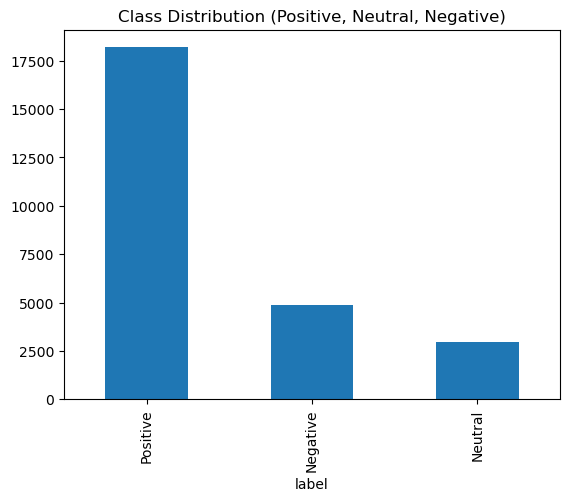

In [7]:
# Label Distribution
label_counts = df['label'].value_counts()
print("Label Distribution:\n", label_counts)
label_counts.plot(kind='bar', title='Class Distribution (Positive, Neutral, Negative)')

Text(0.5, 1.0, 'Review Length by Class')

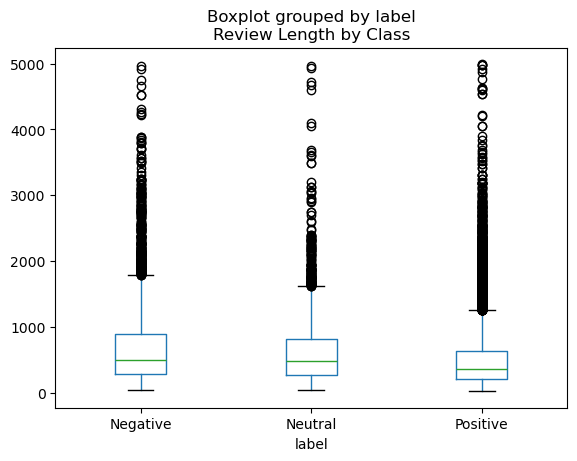

In [8]:
# 2. Review Length Analysis
df['text_length'] = df['text'].apply(len)
df.boxplot(column='text_length', by='label', grid=False)
plt.title('Review Length by Class')

In [9]:
# 3. Word Clouds for Each Class
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')

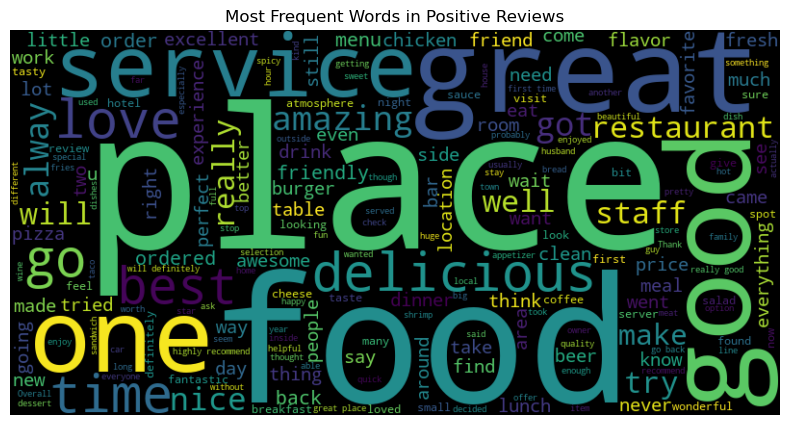

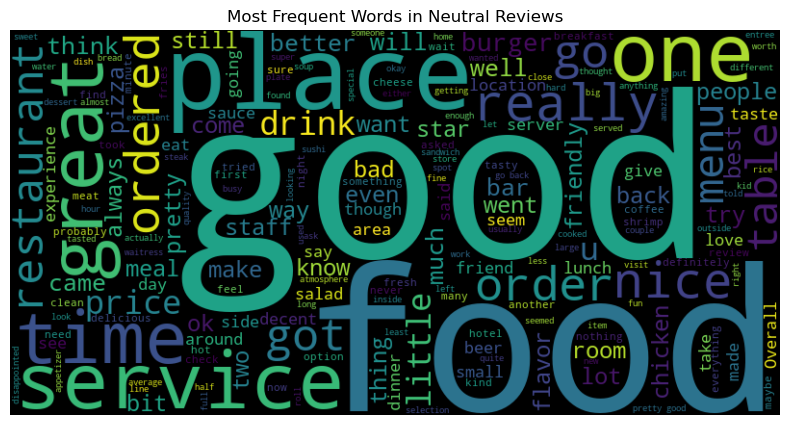

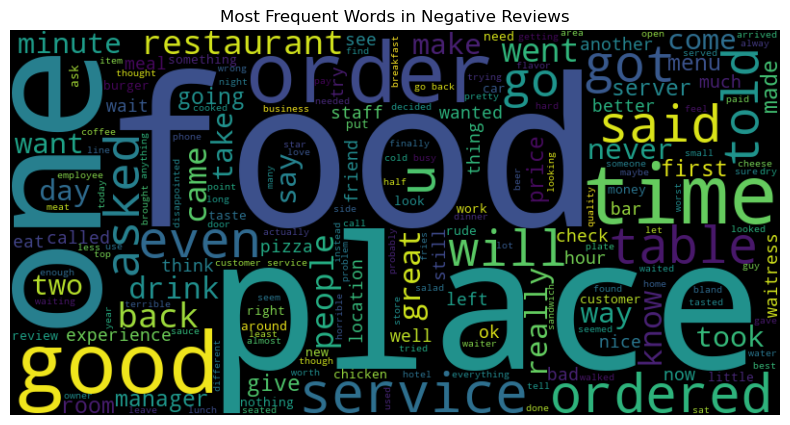

In [10]:
# Positive reviews
positive_text = ' '.join(df[df['label'] == 'Positive']['text'])
generate_wordcloud(positive_text, 'Most Frequent Words in Positive Reviews')

# Neutral reviews
neutral_text = ' '.join(df[df['label'] == 'Neutral']['text'])
generate_wordcloud(neutral_text, 'Most Frequent Words in Neutral Reviews')

# Negative reviews
negative_text = ' '.join(df[df['label'] == 'Negative']['text'])
generate_wordcloud(negative_text, 'Most Frequent Words in Negative Reviews')

In [11]:
# Clean the text data
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters/numbers
    tokens = word_tokenize(text)  # Tokenize
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return ' '.join(filtered_tokens)

df['cleaned_text'] = df['text'].apply(preprocess_text)
X = df['cleaned_text']
y = df['label']

In [12]:
# Initialize TF-IDF with unigrams and bigrams
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)  
X_tfidf = tfidf.fit_transform(X)

In [13]:
# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Initialize SVM with balanced class weights
start_time = time.time()
svm_model = SVC(
    kernel='linear', 
    C=10.0, 
    class_weight='balanced', 
    probability=True, 
)
svm_model.fit(X_train, y_train)
print(f"\nTraining Time: {time.time() - start_time:.2f} seconds")


Training Time: 666.09 seconds



Classification Report (Training Set):
               precision    recall  f1-score   support

    Negative       0.99      1.00      0.99      3878
     Neutral       0.95      1.00      0.97      2363
    Positive       1.00      0.99      0.99     14559

    accuracy                           0.99     20800
   macro avg       0.98      1.00      0.99     20800
weighted avg       0.99      0.99      0.99     20800

[[ 3877     0     1]
 [    0  2363     0]
 [   45   133 14381]]


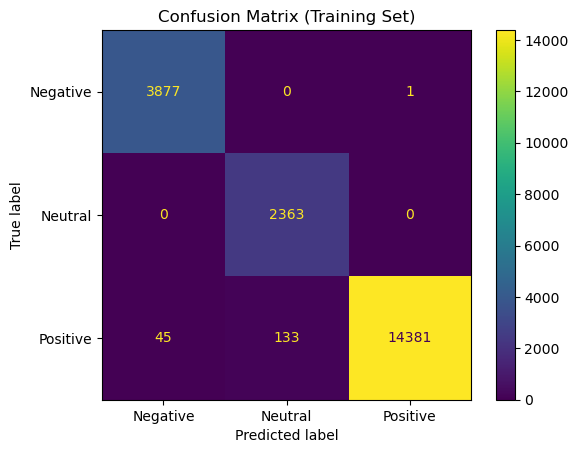

In [15]:
# Predictions on training set
y_train_pred = svm_model.predict(X_train)

# Classification Report (Training Set)
print("\nClassification Report (Training Set):\n", classification_report(y_train, y_train_pred))

# Confusion Matrix (Training Set)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
ConfusionMatrixDisplay(cm_train, display_labels=svm_model.classes_).plot()
plt.title('Confusion Matrix (Training Set)')
plt.show()


Classification Report (Test Set):
               precision    recall  f1-score   support

    Negative       0.71      0.76      0.73       969
     Neutral       0.36      0.37      0.36       591
    Positive       0.91      0.89      0.90      3640

    accuracy                           0.81      5200
   macro avg       0.66      0.67      0.67      5200
weighted avg       0.81      0.81      0.81      5200

[[ 738  139   92]
 [ 161  219  211]
 [ 143  252 3245]]


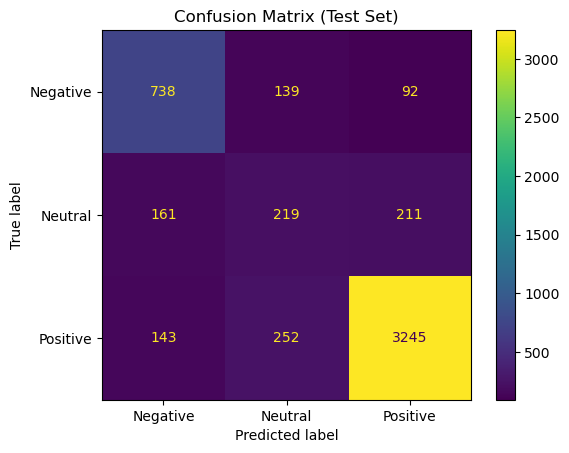

In [16]:
# Predictions on test set
y_pred = svm_model.predict(X_test)

# Classification Report (Test Set)
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred))

# Confusion Matrix (Test Set)
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(cm, display_labels=svm_model.classes_).plot()
plt.title('Confusion Matrix (Test Set)')
plt.show()

In [17]:
# Binarize labels for One-vs-Rest AUC (Test Set)
y_test_bin = label_binarize(y_test, classes=svm_model.classes_)
y_probs = svm_model.predict_proba(X_test)

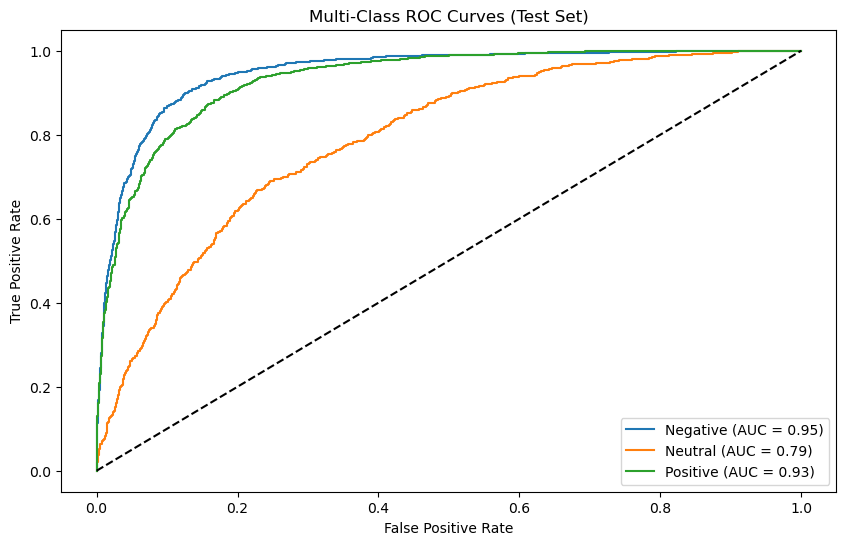

In [18]:
# Compute ROC metrics for each class (Test Set)
fpr, tpr, roc_auc = {}, {}, {}
for i, class_label in enumerate(svm_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

# Plot ROC curves (Test Set)
plt.figure(figsize=(10, 6))
for class_label in svm_model.classes_:
    plt.plot(fpr[class_label], tpr[class_label], 
             label=f'{class_label} (AUC = {roc_auc[class_label]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves (Test Set)')
plt.legend()
plt.show()

In [19]:
# Macro-Average AUC (Test Set)
macro_auc = roc_auc_score(y_test_bin, y_probs, multi_class='ovr', average='macro')
print(f"\nMacro-Average AUC (Test Set): {macro_auc:.2f}")


Macro-Average AUC (Test Set): 0.89


In [20]:
# Perform 5-fold cross-validation
cv_scores = cross_val_score(svm_model, X_tfidf, y, cv=5, scoring='f1_macro',n_jobs=-1)
print(f"\nCross-Validation F1-Macro: {np.mean(cv_scores):.2f} (±{np.std(cv_scores):.2f})")


Cross-Validation F1-Macro: 0.66 (±0.01)


In [21]:
#Interpretability (Top Features) Get feature names and coefficients
feature_names = tfidf.get_feature_names_out()
for i, class_label in enumerate(svm_model.classes_):
    coefs = svm_model.coef_[i].toarray().flatten()
    top_features = sorted(zip(coefs, feature_names), reverse=True)[:10]
    print(f"\nTop 10 Features for {class_label}:")
    for score, word in top_features:
        print(f"{word}: {score:.2f}")


Top 10 Features for Negative:
two stars: 4.72
lamps: 3.83
seared: 3.69
trivia: 3.49
really sure: 3.48
worst: 3.45
find another: 3.42
shit: 3.25
food mediocre: 3.23
handful: 3.23

Top 10 Features for Neutral:
bland: 5.99
worst: 5.08
horrible: 4.84
mediocre: 4.70
terrible: 4.58
disappointing: 4.52
subpar: 4.47
disappointment: 4.37
two stars: 4.21
rude: 4.06

Top 10 Features for Positive:
three stars: 7.07
mediocre: 7.01
okay: 5.74
ok: 5.61
terrible: 5.52
bland: 5.18
purse: 5.09
however: 4.95
unfortunately: 4.92
meh: 4.57


In [22]:
# Define hyperparameters to tune
param_grid = {
    'C': [1, 10],  # Regularization strength
    'kernel': ['linear','rbf']  # Kernel type
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(class_weight='balanced', probability=True, max_iter=1000),
    param_grid=param_grid,
    cv=3,  # Fewer folds for speed
    scoring='f1_macro',  # Metric to optimize
    n_jobs=-1  # Use all CPU cores
)


In [23]:
grid_search.fit(X_train, y_train)
print("\nBest Parameters:", grid_search.best_params_)
print("Best F1-Macro Score:", grid_search.best_score_)


Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best F1-Macro Score: 0.6737472390924936


C:\Users\gaura\anaconda3\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


# SVM model using TF-IDF Vectors with Unigram+Bigram

In [52]:
# Provide the file path of the Excel file
file_path = 'result_table.xlsx'
pd.set_option('display.max_colwidth', None)

# Load the Excel file into a DataFrame
df_result = pd.read_excel(file_path)

# Display the first few rows of the DataFrame
df_result

,Task,Status,Results,Individual Responsible
0,Config of the model trained,done,"SVM Model: kernel='linear', C=10.0, class_weight='balanced'\nTF-IDF: ngram_range=(1,2), max_features=10,000",Gaurav Singh
1,Train Time = ?,done,666.09 seconds,Gaurav Singh
2,Training Data Check,done,"Sample Size: 20,800\nClass Distribution: Positive (14,559), Negative (3,878), Neutral (2,363)",Gaurav Singh
3,Confusion Matrix Built?,done,"Training Confusion Matrix:\n[3877, 0, 1] (Negative)\n[0, 2363, 0] (Neutral)\n[45, 133, 14381] (Positive)",Gaurav Singh
4,F1 Score for Positive = ?,done,Training: 0.99,Gaurav Singh
5,F1 Score for Negative = ?,done,Training: 0.99,Gaurav Singh
6,AUC plotted?,done,Yes (Multi-Class ROC curves for Test Set),Gaurav Singh
7,AUC = ?,done,"Negative: 0.95,Neutral: 0.80,Positive: 0.94",Gaurav Singh
8,Accuracy computed?,done,Yes,Gaurav Singh
9,Accuracy = ?,done,Training: 99%,Gaurav Singh
